# Getting started with `chem`

Sanity check that the `chem` kernel and package are wired up correctly.

In [1]:
import chem

chem.__version__

'0.1.0'

## ChEMBL activities for BRAF (UniProt entry name lookup)

`chem.chembl.download_activities` accepts a ChEMBL target id, a UniProt
accession, or a UniProt entry name (mnemonic) such as `BRAF_HUMAN` — it
resolves the id, calls the ChEMBL REST API directly (no
`chembl_webresource_client`), keeps only records with a pChEMBL value,
filters by molecular weight, and (when `normalize_smiles=True`) standardizes
each compound via the ChEMBL Structure Pipeline and aggregates duplicate
compounds into count/mean/median/std.

In [2]:
from chem import chembl

n = chembl.download_activities(
    "BRAF_HUMAN",
    mw=[250, 650],
    normalize_smiles=True,
    output="braf_activities.tsv",
)
n

[08:42:15] Initializing Normalizer
download_activities(id='BRAF_HUMAN', mw=[250, 650], normalize_smiles=True, output='braf_activities.tsv')


fetching activities for CHEMBL5145:   0%|          | 0/9836 [00:00<?, ?rec/s]

fetching activities for CHEMBL5145:  20%|██        | 2000/9836 [00:08<00:34, 228.42rec/s]

fetching activities for CHEMBL5145:  31%|███       | 3000/9836 [00:17<00:41, 164.47rec/s]

fetching activities for CHEMBL5145:  41%|████      | 4000/9836 [00:27<00:44, 131.25rec/s]

...

fetching activities for CHEMBL5145:  92%|█████████▏| 9000/9836 [01:18<00:08, 99.53rec/s] 

fetching activities for CHEMBL5145: 100%|██████████| 9836/9836 [01:28<00:00, 95.72rec/s]

fetching activities for CHEMBL5145: 100%|██████████| 9836/9836 [01:31<00:00, 107.05rec/s]


wrote 5623 rows to braf_activities.tsv


5623

### Preview the result

In [3]:
import pandas as pd

df = pd.read_csv("braf_activities.tsv", sep="\t")
print(df.size)
df.sort_values("pchembl_mean", ascending=False).head(10)

44984


,parent_chembl_id,target_chembl_id,smiles,mw,n,pchembl_mean,pchembl_median,pchembl_std
4574,CHEMBL5885861,CHEMBL5145,CCNc1nc(-c2cc(NC(=O)c3cccc(S(C)(=O)=O)c3)ccc2C...,495.61,2,10.70,10.70,0.0
161,CHEMBL500659,CHEMBL5145,Cn1cc(-c2ccc3c(c2)CC/C3=N\O)c(-c2ccncc2)n1,304.35,1,10.70,10.70,0.0
155,CHEMBL498344,CHEMBL5145,O/N=C1\CCc2cc(-c3cn([C@@H]4CCC[C@H](O)C4)nc3-c...,388.47,1,10.40,10.40,0.0
5545,CHEMBL5850574,CHEMBL5145,COc1ccc(S(=O)(=O)NCCCNc2nccc(-c3c(-c4ccc(F)c(O...,554.63,1,10.30,10.30,0.0
151,CHEMBL527029,CHEMBL5145,OCCCn1cc(-c2ccc3c(c2)CC/C3=N\O)c(-c2ccncc2)n1,348.41,1,10.30,10.30,0.0
2227,CHEMBL3651664,CHEMBL5145,CCCS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C(C)(C)C)nc2-...,466.97,1,10.10,10.10,0.0
2245,CHEMBL3651683,CHEMBL5145,CS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C3CC3)nc2-c2ccn...,475.94,1,10.10,10.10,0.0
5551,CHEMBL5982580,CHEMBL5145,COc1ccc(S(=O)(=O)NCCCNc2nccc(-c3c(-c4ccc(F)c(O...,538.56,1,10.10,10.10,0.0
154,CHEMBL521562,CHEMBL5145,O/N=C1\CCc2cc(-c3cn([C@@H]4CCC[C@@H](O)C4)nc3-...,388.47,1,10.05,10.05,0.0
2278,CHEMBL3651613,CHEMBL5145,CCS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C(C)(C)C)nc2-c...,550.09,1,10.00,10.00,0.0


### Draw the most potent compound

CHEMBL5885861 pchembl_mean= 10.7 n= 2


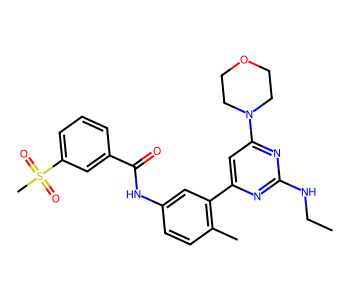

In [4]:
from rdkit import Chem
from rdkit.Chem.Draw import MolToImage

top = df.sort_values("pchembl_mean", ascending=False).iloc[0]
mol = Chem.MolFromSmiles(top["smiles"])
print(top["parent_chembl_id"], "pchembl_mean=", top["pchembl_mean"], "n=", top["n"])
MolToImage(mol, size=(350, 300))

## RCSB PDB structures for thrombin (UniProt entry name lookup)

`chem.rcsb.download_structures` accepts the same three id forms as
`chem.chembl.download_activities` (ChEMBL target id, UniProt accession, or
UniProt entry name). It resolves the id to a UniProt accession, finds every
PDB entry annotated with that accession via the RCSB Search API, optionally
filters by resolution (entries without one, e.g. NMR structures, are dropped
whenever a threshold is given), and downloads each entry's structure file(s).
Files already present in `outdir` are left alone, so re-running only fetches
what's missing.

In [1]:
from chem import rcsb

n = rcsb.download_structures(
    "THRB_HUMAN",
    resolution_thres=1.2,
    outdir="data",
)
n

download_structures(id='THRB_HUMAN', resolution_thres=1.2, outdir='data', filetype='cif')


fetching resolution metadata:   0%|          | 0/3 [00:00<?, ?batch/s]

fetching resolution metadata:  33%|███▎      | 1/3 [00:00<00:01,  1.54batch/s]

fetching resolution metadata:  67%|██████▋   | 2/3 [00:01<00:00,  1.60batch/s]

fetching resolution metadata: 100%|██████████| 3/3 [00:01<00:00,  1.60batch/s]

...

downloading structures to data:  83%|████████▎ | 5/6 [00:00<00:00,  9.34entry/s]

downloading structures to data: 100%|██████████| 6/6 [00:00<00:00,  9.44entry/s]

downloading structures to data: 100%|██████████| 6/6 [00:00<00:00,  9.26entry/s]


wrote 6 structures to data


6

### View one of the downloaded structures

In [2]:
import os

import py3Dmol

cif_files = sorted(f for f in os.listdir("data") if f.endswith(".cif"))
print(len(cif_files), "structures downloaded, e.g.", cif_files[:5])

with open(os.path.join("data", cif_files[0])) as f:
    view = py3Dmol.view(width=500, height=400)
    view.addModel(f.read(), "cif")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    view.zoomTo()
view.show()

6 structures downloaded, e.g. ['4UD9.cif', '4UDW.cif', '4UE7.cif', '4UEH.cif', '5AF9.cif']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.